# Topic 1 — Descriptive Analysis & Accessibility Pipeline
### Analysis strategy

| Step | Output file | Purpose |
|------|------------|--------|
| **1** | `01_kwb_buurten_clean.csv` | KWB neighbourhood demographics; `02_amenities_clean.csv` with utilitarian / leisure scores |
| **2** | `04_bikeshed_accessibility_10min.csv` | DuckDB query: for each buurt, sum amenities reachable by bike within 10 min |
| **3** | `04_bikeshed_accessibility_3km.csv` | Same as step 2 but distance-based (≤ 3 km) |
| **4** | `05_accessibility_context_buurten.csv`, `05b_gemeente_accessibility_typology.csv` | Merge KWB + bike-shed; classify neighbourhood & gemeente types |
| **5** | `03_odin_*.csv`, `03b_brabant_cyclable_trips_with_access.csv` | Load & clean ODiN 2024 + 2022; weight normalisation; life-stage classification; weighted aggregation |
| **6** | `table_rq1_*.csv`, `table_rq2_*.csv` | Analysis tables: Eindhoven region summary, RQ1/RQ2 municipality tables, policy priority score |
| **7** | `fig_rq1_accessibility_by_type.png` | Bar chart: avg accessibility by neighbourhood type |
| **8** | `fig_rq1_cycling_share_heatmap.png` | Heatmap: cycling share by life stage × urbanity |
| **9** | `fig_rq2_amenity_mix_eindhoven_region.png` | Scatter: utilitarian vs leisure/social access, sized by elderly share |
| **10** | `latex_tables/` | Export four summary tables as LaTeX for the report |

Amenities are split into two conceptual groups:
- **Utilitarian**: pharmacy, primary school, bus stop, GP, childcare, supermarket, train station, secondary school, hospital
- **Leisure / social**: fast food, hospitality, clothing shop, restaurant, sports facility, drinking-water point


## 0. Install / Import

In [1]:
# Uncomment to install DuckDB if not available in the environment
#pip install duckdb

## 1. Paths & Setup

Define working directories and confirm input files exist.

In [2]:
import csv
import pandas as pd
import numpy as np
from pathlib import Path
import duckdb
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# ── Peek at buurt-to-buurt travel-time matrix column names ───────────────────
path = "data/buurt_to_buurt.csv"
with open(path, "r", encoding="utf-8-sig") as f:
    reader = csv.reader(f)
    header = next(reader)

print(header[:80])


['buurt_ori_id', 'buurt_id', 'walk_2025_minutes', 'walk_2025_distance', 'walk_2025_detour_factor', 'bike_2025_smart_minutes', 'bike_2025_smart_distance', 'bike_2025_smart_detour_factor', 'ebike_2025_smart_minutes', 'ebike_2025_smart_distance', 'ebike_2025_smart_detour_factor', 'car_2025_minutes', 'car_2025_distance', 'car_2025_detour_factor', 'truck_2025_minutes', 'truck_2025_distance', 'truck_2025_detour_factor', 'ov_morning_minutes', 'ov_morning_distance', 'ov_morning_detour_factor', 'ov_midday_minutes', 'ov_midday_distance', 'ov_midday_detour_factor', 'ov_evening_minutes', 'ov_evening_distance', 'ov_evening_detour_factor', 'ov_weekend_morning_minutes', 'ov_weekend_morning_distance', 'ov_weekend_morning_detour_factor', 'bike_2040_smart_minutes', 'bike_2040_smart_distance', 'bike_2040_smart_detour_factor', 'bike_2040_utr_minutes', 'bike_2040_utr_distance', 'bike_2040_utr_detour_factor', 'ebike_2040_smart_minutes', 'ebike_2040_smart_distance', 'ebike_2040_smart_detour_factor']


In [3]:
# ── Directory structure ──────────────────────────────────────────────────────
HERE = Path.cwd()
DATA = HERE / "data"
OUT  = HERE / "output"
OUT.mkdir(parents=True, exist_ok=True)

B2B_PATH     = DATA / "buurt_to_buurt.csv"                   # buurt-to-buurt travel times
KWB_PATH     = DATA / "kwb2025.xlsx"                         # CBS neighbourhood statistics
AMENITY_PATH = DATA / "voorzieningen_per_buurt_klasse.csv"   # amenity counts per buurt

print(f"KWB path    : {KWB_PATH}")
print(f"Amenity path: {AMENITY_PATH}")

KWB path    : c:\Users\joane\Documents\MASTER\Q4\AI BUSINESS OPERATIONS\1BM130 project\data\kwb2025.xlsx
Amenity path: c:\Users\joane\Documents\MASTER\Q4\AI BUSINESS OPERATIONS\1BM130 project\data\voorzieningen_per_buurt_klasse.csv


## 2. Load & Clean Source Data

### 2a. KWB neighbourhood statistics

Selected KWB columns used downstream:

| Column | Meaning | Used for |
|--------|---------|----------|
| `a_inw` | Total population | Population weights |
| `a_65_oo` | Population 65+ | Elderly share (RQ2) |
| `a_hh_m_k` / `a_hh` | Households with/without children | Family-household share |
| `ste_oad` | Address density (proxy for urbanity) | Neighbourhood typology |
| `p_1gezw` | % single-family homes | VINEX-like typology proxy |
| `g_afs_hp` | Distance to GP (km) | Utilitarian accessibility (Topic 2) |
| `g_afs_kv` | Distance to supermarket (km) | Utilitarian accessibility (Topic 2) |

### 2b. Amenity dataset

Amenity classes (`0`, `1`, `2+`) are converted to counts (0/1/2).
Composite scores are computed as simple sums:

| Score | Columns included |
|-------|------------------|
| `utilitarian_amenities` | apotheek, basisschool, bushalte, huisarts, kinderopvang, supermarkt, treinstation, voortgezet_onderwijs, ziekenhuis |
| `leisure_social_amenities` | fastfood, horeca, kledingwinkel, restaurant, sportterrein, aantal_drinkwaterpunt |
| `total_amenities` | sum of both |


In [4]:
def to_number(s):
    """
    Converts CBS-style values to numeric.
    Missing/suppressed values are often stored as '.'
    and decimals can use commas.
    """
    return (
        s.astype(str)
         .str.replace(",", ".", regex=False)
         .replace({".": np.nan, "nan": np.nan})
         .pipe(pd.to_numeric, errors="coerce")
    )

# ── 2a. KWB: load, filter to Buurt level, select & rename columns ───────────

kwb = pd.read_excel(
    KWB_PATH,
    sheet_name="KWB2025",
    dtype=str
)

kwb = kwb[kwb["recs"] == "Buurt"].copy()
keep_cols = [
    "gwb_code_10", "gwb_code_8", "gwb_code", "regio", "gm_naam", "recs",
    "a_inw", "a_00_14", "a_15_24", "a_25_44", "a_45_64", "a_65_oo",
    "a_hh", "a_1p_hh", "a_hh_z_k", "a_hh_m_k",
    "bev_dich", "ste_oad",
    "p_1gezw", "p_mgezw",
    "g_afs_hp", "g_afs_gs", "g_afs_kv", "g_afs_sc", "g_3km_sc"
]

kwb = kwb[keep_cols].copy()
num_cols = [c for c in keep_cols if c not in ["gwb_code_10", "gwb_code_8", "gwb_code", "regio", "gm_naam", "recs"]]
for col in num_cols:
    kwb[col] = to_number(kwb[col])
kwb = kwb.rename(columns={
    "gwb_code": "buurtcode",
    "regio": "buurtnaam",
    "gm_naam": "gemeente"
})

# municipality code from BU07721110 -> 0772
kwb["gm_code"] = kwb["gwb_code_8"].str[:4]
kwb["gm_code_int"] = pd.to_numeric(kwb["gm_code"], errors="coerce").astype("Int64")
kwb["elderly_share"] = kwb["a_65_oo"] / kwb["a_inw"]
kwb["children_share"] = kwb["a_00_14"] / kwb["a_inw"]
kwb["family_household_share"] = kwb["a_hh_m_k"] / kwb["a_hh"]
kwb.to_csv(OUT / "01_kwb_buurten_clean.csv", index=False)


# ── 2b. Amenities: convert ordinal classes to counts, build composite scores ─

amen = pd.read_csv(AMENITY_PATH, dtype=str)
amenity_class_cols = [c for c in amen.columns if c.startswith("klasse_")]

def amenity_class_to_count(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    if x == "2+":
        return 2
    return pd.to_numeric(x, errors="coerce")

for col in amenity_class_cols:
    amen[col] = amen[col].apply(amenity_class_to_count)

amen["aantal_drinkwaterpunt"] = pd.to_numeric(amen["aantal_drinkwaterpunt"], errors="coerce").fillna(0)

utilitarian_cols = [
    "klasse_apotheek",
    "klasse_basisschool",
    "klasse_bushalte",
    "klasse_huisarts",
    "klasse_kinderopvang",
    "klasse_supermarkt",
    "klasse_treinstation",
    "klasse_voortgezet_onderwijs",
    "klasse_ziekenhuis"
]
leisure_social_cols = [
    "klasse_fastfood",
    "klasse_horeca",
    "klasse_kledingwinkel",
    "klasse_restaurant",
    "klasse_sportterrein",
    "aantal_drinkwaterpunt"
]

amen["utilitarian_amenities"] = amen[utilitarian_cols].sum(axis=1, skipna=True)
amen["leisure_social_amenities"] = amen[leisure_social_cols].sum(axis=1, skipna=True)
amen["total_amenities"] = amen["utilitarian_amenities"] + amen["leisure_social_amenities"]
amen.to_csv(OUT / "02_amenities_clean.csv", index=False)

print("Saved:")
print(OUT / "01_kwb_buurten_clean.csv")
print(OUT / "02_amenities_clean.csv")
print("KWB shape:", kwb.shape)
print("Amenity shape:", amen.shape)

Saved:
c:\Users\joane\Documents\MASTER\Q4\AI BUSINESS OPERATIONS\1BM130 project\output\01_kwb_buurten_clean.csv
c:\Users\joane\Documents\MASTER\Q4\AI BUSINESS OPERATIONS\1BM130 project\output\02_amenities_clean.csv
KWB shape: (14729, 30)
Amenity shape: (14515, 19)


## 3. Bike-Shed Accessibility (DuckDB)

For each origin buurt, a **bike-shed** is defined as all destination buurten reachable within a time/distance threshold.
Amenity scores of all reachable destinations are summed to produce a single accessibility index per origin.

| Query | Threshold | Output file |
|-------|-----------|-------------|
| 10-minute | `bike_2025_smart_minutes ≤ 10` | `04_bikeshed_accessibility_10min.csv` |
| 3-km | `bike_2025_smart_distance ≤ 3 000 m` | `04_bikeshed_accessibility_3km.csv` |

DuckDB is used for the spatial join because the buurt-to-buurt matrix (~200 M rows) is too large for in-memory pandas.
Both queries follow the same pattern: normalise buurt codes → filter by threshold → `LEFT JOIN` amenities → `GROUP BY` origin.


In [5]:
# ── 3a. 10-minute bike-shed (primary accessibility metric) ─────────────────
AMENITIES_CLEAN_PATH = OUT / "02_amenities_clean.csv"
OUTPUT_PATH = OUT / "04_bikeshed_accessibility_10min.csv"

con = duckdb.connect(database=":memory:")
query = f"""
COPY (
    WITH amenities AS (
        SELECT
            buurtcode,
            utilitarian_amenities,
            leisure_social_amenities,
            total_amenities
        FROM read_csv_auto('{AMENITIES_CLEAN_PATH}', all_varchar=false)
    ),

    b2b_clean AS (
        SELECT
            CASE 
                WHEN starts_with(buurt_ori_id, 'BU') THEN buurt_ori_id
                ELSE 'BU' || lpad(buurt_ori_id, 8, '0')
            END AS origin_buurtcode,

            CASE 
                WHEN starts_with(buurt_id, 'BU') THEN buurt_id
                ELSE 'BU' || lpad(buurt_id, 8, '0')
            END AS destination_buurtcode,

            try_cast(bike_2025_smart_minutes AS DOUBLE) AS bike_minutes,
            try_cast(bike_2025_smart_distance AS DOUBLE) AS bike_distance
        FROM read_csv(
            '{B2B_PATH}',
            header=true,
            delim=',',
            all_varchar=true
        )
    )

    SELECT
        b.origin_buurtcode AS buurtcode,
        COUNT(*) AS reachable_buurten_10min,
        AVG(b.bike_minutes) AS avg_bike_minutes_to_reachable,
        AVG(b.bike_distance) AS avg_bike_distance_to_reachable,

        SUM(COALESCE(a.total_amenities, 0)) AS bikeshed_total_amenities,
        SUM(COALESCE(a.utilitarian_amenities, 0)) AS bikeshed_utilitarian_amenities,
        SUM(COALESCE(a.leisure_social_amenities, 0)) AS bikeshed_leisure_social_amenities

    FROM b2b_clean b
    LEFT JOIN amenities a
        ON b.destination_buurtcode = a.buurtcode
    WHERE b.bike_minutes <= 10
    GROUP BY b.origin_buurtcode
) TO '{OUTPUT_PATH}' WITH (HEADER, DELIMITER ',');
"""

con.execute(query)

print("Saved:", OUTPUT_PATH)

Saved: c:\Users\joane\Documents\MASTER\Q4\AI BUSINESS OPERATIONS\1BM130 project\output\04_bikeshed_accessibility_10min.csv


In [6]:
# ── 3b. 3-km bike-shed (robustness / sensitivity check) ────────────────────
OUTPUT_PATH = OUT / "04_bikeshed_accessibility_10min.csv"
OUTPUT_PATH_3KM = OUT / "04_bikeshed_accessibility_3km.csv"

query_3km = f"""
COPY (
    WITH amenities AS (
        SELECT
            buurtcode,
            utilitarian_amenities,
            leisure_social_amenities,
            total_amenities
        FROM read_csv_auto('{AMENITIES_CLEAN_PATH}', all_varchar=false)
    ),

    b2b_clean AS (
        SELECT
            CASE 
                WHEN starts_with(buurt_ori_id, 'BU') THEN buurt_ori_id
                ELSE 'BU' || lpad(buurt_ori_id, 8, '0')
            END AS origin_buurtcode,

            CASE 
                WHEN starts_with(buurt_id, 'BU') THEN buurt_id
                ELSE 'BU' || lpad(buurt_id, 8, '0')
            END AS destination_buurtcode,

            try_cast(bike_2025_smart_minutes AS DOUBLE) AS bike_minutes,
            try_cast(bike_2025_smart_distance AS DOUBLE) AS bike_distance
        FROM read_csv(
            '{B2B_PATH}',
            header=true,
            delim=',',
            all_varchar=true
        )
    )

    SELECT
        b.origin_buurtcode AS buurtcode,
        COUNT(*) AS reachable_buurten_3km,
        AVG(b.bike_minutes) AS avg_bike_minutes_to_reachable_3km,
        AVG(b.bike_distance) AS avg_bike_distance_to_reachable_3km,

        SUM(COALESCE(a.total_amenities, 0)) AS bikeshed_total_amenities_3km,
        SUM(COALESCE(a.utilitarian_amenities, 0)) AS bikeshed_utilitarian_amenities_3km,
        SUM(COALESCE(a.leisure_social_amenities, 0)) AS bikeshed_leisure_social_amenities_3km

    FROM b2b_clean b
    LEFT JOIN amenities a
        ON b.destination_buurtcode = a.buurtcode
    WHERE b.bike_distance <= 3000
    GROUP BY b.origin_buurtcode
) TO '{OUTPUT_PATH_3KM}' WITH (HEADER, DELIMITER ',');
"""

con.execute(query_3km)

print("Saved:", OUTPUT_PATH_3KM)

Saved: c:\Users\joane\Documents\MASTER\Q4\AI BUSINESS OPERATIONS\1BM130 project\output\04_bikeshed_accessibility_3km.csv


## 4. Sanity Check — Bike-Shed Output

Verify shape and key statistics of the 10-minute bike-shed table before proceeding.

In [7]:
# ── 4. Quick shape / descriptive stats check ────────────────────────────────
bike = pd.read_csv(OUT / "04_bikeshed_accessibility_10min.csv")
#print(bike.shape)
#print(bike.head())
#print(bike.describe())

## 5. Neighbourhood & Gemeente Typology

KWB demographics are merged with the bike-shed accessibility table.
Two classification levels are produced:

**Buurt level** (`neighbourhood_type`)

| Type | Criterion |
|------|-----------|
| High-density urban | `ste_oad ≥ 75th percentile` |
| Low-density family / VINEX-like | `ste_oad < 50th percentile` AND `family_hh_share ≥ 60th pct` AND `p_1gezw ≥ 60th pct` |
| Other | Everything else |

**Gemeente level** (`dominant_type`)

Population-weighted average accessibility and neighbourhood-type shares are aggregated per municipality.
A gemeente is classified by its dominant buurt type (threshold ≥ 50 %).
This gemeente-level typology is later joined onto ODiN trip data for RQ1.


In [8]:
# ── 5. Merge KWB + bike-shed; classify neighbourhood and gemeente types ──────
kwb = pd.read_csv(OUT / "01_kwb_buurten_clean.csv")
bike = pd.read_csv(OUT / "04_bikeshed_accessibility_10min.csv")

# Merge KWB neighbourhood characteristics with 10-minute bike-shed accessibility
access = kwb.merge(bike, on="buurtcode", how="left")

# Fill missing bike-shed values with 0 only for accessibility columns
access_cols = [
    "reachable_buurten_10min",
    "avg_bike_minutes_to_reachable",
    "avg_bike_distance_to_reachable",
    "bikeshed_total_amenities",
    "bikeshed_utilitarian_amenities",
    "bikeshed_leisure_social_amenities",
]
for col in access_cols:
    access[col] = access[col].fillna(0)

# Demographic shares
access["elderly_share"] = access["a_65_oo"] / access["a_inw"].replace(0, np.nan)
access["children_share"] = access["a_00_14"] / access["a_inw"].replace(0, np.nan)
access["family_household_share"] = access["a_hh_m_k"] / access["a_hh"].replace(0, np.nan)

# Neighbourhood typology at the BUURT level (RQ1)
density_q75 = access["ste_oad"].quantile(0.75)
density_q50 = access["ste_oad"].quantile(0.50)
family_q60 = access["family_household_share"].quantile(0.60)
single_family_q60 = access["p_1gezw"].quantile(0.60)

conditions = [
    access["ste_oad"] >= density_q75,
    (
        (access["ste_oad"] < density_q50)
        & (access["family_household_share"] >= family_q60)
        & (access["p_1gezw"] >= single_family_q60)
    ),
]
choices = [
    "High-density urban neighbourhood",
    "Low-density family / VINEX-like neighbourhood",
]
access["neighbourhood_type"] = np.select(conditions, choices, default="Other neighbourhood")

# Save buurt-level dataset
access.to_csv(OUT / "05_accessibility_context_buurten.csv", index=False)

def pop_weighted(g, value_col, weight_col="a_inw"):
    s = g[[value_col, weight_col]].dropna()
    if s[weight_col].sum() == 0:
        return np.nan
    return float(np.average(s[value_col], weights=s[weight_col]))

gem_access = (
    access
    .groupby("gm_code_int", dropna=True)
    .apply(lambda g: pd.Series({
        "gemeente": g["gemeente"].iloc[0] if "gemeente" in g.columns else np.nan,
        "n_buurten": len(g),
        "population": g["a_inw"].sum(),
        "pop_weighted_total_access": pop_weighted(g, "bikeshed_total_amenities"),
        "pop_weighted_utilitarian_access": pop_weighted(g, "bikeshed_utilitarian_amenities"),
        "pop_weighted_leisure_social_access": pop_weighted(g, "bikeshed_leisure_social_amenities"),
        "share_high_density": float((g["neighbourhood_type"] == "High-density urban neighbourhood").mean()),
        "share_vinex_like":   float((g["neighbourhood_type"] == "Low-density family / VINEX-like neighbourhood").mean()),
        "elderly_share":      pop_weighted(g, "elderly_share"),
        "family_hh_share":    pop_weighted(g, "family_household_share"),
    }), include_groups=False)
    .reset_index()
    .rename(columns={"gm_code_int": "Wogem_DANS24"})
)

# Dominant-type classification at GEMEENTE level (>=50% threshold)
def dominant_type(row, thresh=0.50):
    if row["share_high_density"] >= thresh:
        return "High-density urban gemeente"
    if row["share_vinex_like"] >= thresh:
        return "VINEX-like gemeente"
    return "Mixed gemeente"

gem_access["dominant_type"] = gem_access.apply(dominant_type, axis=1)
gem_access.to_csv(OUT / "05b_gemeente_accessibility_typology.csv", index=False)

# Original summary table by neighbourhood type 
summary_type = (
    access
    .groupby("neighbourhood_type")
    .agg(
        n_buurten=("buurtcode", "count"),
        avg_population=("a_inw", "mean"),
        avg_address_density=("ste_oad", "mean"),
        avg_population_density=("bev_dich", "mean"),
        avg_total_access=("bikeshed_total_amenities", "mean"),
        avg_utilitarian_access=("bikeshed_utilitarian_amenities", "mean"),
        avg_leisure_social_access=("bikeshed_leisure_social_amenities", "mean"),
        avg_elderly_share=("elderly_share", "mean"),
        avg_family_household_share=("family_household_share", "mean"),
    )
    .reset_index()
)
summary_type.to_csv(OUT / "table_accessibility_by_neighbourhood_type.csv", index=False)

print("Buurten classified:", access["neighbourhood_type"].value_counts().to_dict())
print("Gemeenten by dominant type:", gem_access["dominant_type"].value_counts().to_dict())
print("Access shape:", access.shape, "| Gem access shape:", gem_access.shape)


Buurten classified: {'Other neighbourhood': 9016, 'High-density urban neighbourhood': 3663, 'Low-density family / VINEX-like neighbourhood': 2050}
Gemeenten by dominant type: {'Mixed gemeente': 285, 'High-density urban gemeente': 43, 'VINEX-like gemeente': 14}
Access shape: (14729, 37) | Gem access shape: (342, 12)


## 6. Load & Process ODiN Trip Data (2022 + 2024)

Two ODiN datasets are used:

| Dataset | Scope | N trips (clean) |
|---------|-------|-----------------|
| ODiN 2024 | Full Netherlands | ~8 100 |
| ODiN 2022 | Noord-Brabant only (pre-filtered) | ~22 500 |

**Key processing steps:**
- Parse `FactorV` trip weights (ODiN 2024 uses dot-separated integers; 2022 uses plain integers — scales differ by ~10⁶).
- Weights are rescaled within each year so `sum(weights) = N` before pooling, ensuring neither year dominates.
- Trip-purpose flags: utilitarian = motives 1–5; leisure/social = motives 6–8.
- Life stage is derived from age code (`KLeeft`) and household composition (`HHSam_DANS24`).
- Cyclable trips are filtered to `KAfstV` 1–6 (≤ 7.5 km) so the cycling-share denominator matches the accessibility metric's 10-min bike-shed.

Output files produced by `weighted_aggregation()`:

| File | Grouping | Used for |
|------|----------|----------|
| `03_odin_rq1_life_stage_urbanity.csv` | life stage × urbanity | Figure 2 |
| `03_odin_rq1_life_stage_municipality.csv` | municipality × life stage | RQ1 regression |
| `03_odin_rq2_eindhoven_elderly_municipality.csv` | municipality (elderly, Eindhoven) | RQ2 descriptives |
| `03b_brabant_cyclable_trips_with_access.csv` | trip-level with gemeente access scores | Topic 2 input |


In [9]:
ODIN_PATH = DATA / "odin2024_full.csv"
ODIN2022_PATH = DATA / "odin2022_brabant.csv"
CODEBOOK_PATH = DATA / "ODiN2024_Codeboek_DANS_v2.0 (1).xlsx"

def parse_weight(x):
    """
    ODiN weights are stored with dots in the CSV. For weighted shares,
    the absolute scale does not matter; we need a consistent numeric value.
    """
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    if x in ["#NULL!", ""]:
        return np.nan
    return pd.to_numeric(x.replace(".", ""), errors="coerce")

use_cols = [
    "Verpl", "KHvm", "Hvm", "KLeeft", "HHSam_DANS24",
    "Prov", "Corop", "Wogem_DANS24", "Sted", "GemGr",
    "KMotiefV", "KAfstV", "FactorV",
]

odin = pd.read_csv(
    ODIN_PATH, sep=";", usecols=use_cols, dtype=str, na_values=["#NULL!"]
)

for col in use_cols:
    if col != "FactorV":
        odin[col] = pd.to_numeric(odin[col], errors="coerce")

odin["weight_v"] = odin["FactorV"].apply(parse_weight)

# Keep valid new trips
trips = odin[
    (odin["Verpl"] == 1)
    & (odin["KHvm"].notna())
    & (odin["weight_v"].notna())
].copy()

# Mode indicators
trips["is_bike"] = (trips["KHvm"] == 5).astype(int)
trips["is_car"] = trips["KHvm"].isin([1, 2]).astype(int)

# Trip-purpose indicators
# KMotiefV: 1 work, 2 business, 3 services/personal care, 4 shopping,
# 5 education, 6 visiting, 7 social-recreational, 8 touring/walking, 9 other
trips["is_utilitarian_trip"] = trips["KMotiefV"].isin([1, 2, 3, 4, 5]).astype(int)
trips["is_leisure_social_trip"] = trips["KMotiefV"].isin([6, 7, 8]).astype(int)

def classify_life_stage(row):
    age = row["KLeeft"]
    hh = row["HHSam_DANS24"]
    if pd.isna(age):
        return np.nan
    if age in [2, 3, 4]:
        return "Child/Teen (<18)"
    if age in [5, 6, 7]:
        return "Young Adult (18-29)"
    if age in [8, 9, 10, 11, 12] and hh in [3, 4]:
        return "Family w/ Kids"
    if age in [8, 9, 10, 11, 12]:
        return "Mid-life No Kids (30-54)"
    if age in [13, 14, 15]:
        return "Older Adult (55-69)"
    if age in [16, 17, 18]:
        return "Senior (70+)"
    return np.nan

trips["life_stage"] = trips.apply(classify_life_stage, axis=1)

def weighted_aggregation(df, group_cols):
    rows = []
    for keys, sub in df.groupby(group_cols, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)
        weight_sum = sub["weight_v"].sum()
        row = dict(zip(group_cols, keys))
        row["n_trips_unweighted"] = len(sub)
        row["weighted_trips"] = weight_sum
        row["cycling_share"] = (sub["is_bike"] * sub["weight_v"]).sum() / weight_sum
        row["car_share"] = (sub["is_car"] * sub["weight_v"]).sum() / weight_sum
        row["utilitarian_trip_share"] = (sub["is_utilitarian_trip"] * sub["weight_v"]).sum() / weight_sum
        row["leisure_social_trip_share"] = (sub["is_leisure_social_trip"] * sub["weight_v"]).sum() / weight_sum
        rows.append(row)
    return pd.DataFrame(rows)

# -----------------------------------------------------------
# Brabant subset (province 11) + ODiN 2022 already Brabant-filtered
# -----------------------------------------------------------
brabant_2024 = trips[trips["Prov"] == 11].copy()

odin22 = pd.read_csv(ODIN2022_PATH)
odin22 = odin22.rename(columns={"WoGem": "Wogem_DANS24", "HHSam": "HHSam_DANS24"})
for col in ["KAfstV", "KHvm", "KMotiefV", "KLeeft", "Sted"]:
    odin22[col] = pd.to_numeric(odin22[col].astype(str).replace("#NULL!", np.nan), errors="coerce")
odin22["weight_v"] = pd.to_numeric(odin22["FactorV"], errors="coerce")
odin22["is_bike"] = (odin22["KHvm"] == 5).astype(int)
odin22["is_car"] = odin22["KHvm"].isin([1, 2]).astype(int)
odin22["is_utilitarian_trip"] = odin22["KMotiefV"].isin([1, 2, 3, 4, 5]).astype(int)
odin22["is_leisure_social_trip"] = odin22["KMotiefV"].isin([6, 7, 8]).astype(int)
odin22 = odin22[odin22["KHvm"].notna() & odin22["weight_v"].notna()].copy()
odin22["life_stage"] = odin22.apply(classify_life_stage, axis=1)

# -----------------------------------------------------------
# WEIGHT NORMALIZATION (fix for the ODiN 2022 vs 2024 scale mismatch)
# -----------------------------------------------------------
def rescale_to_n(df):
    w = df["weight_v"].astype(float)
    total = w.sum()
    if total > 0:
        df = df.copy()
        df["weight_v"] = w * len(df) / total
    return df

brabant_2024 = rescale_to_n(brabant_2024)
odin22 = rescale_to_n(odin22)
brabant = pd.concat([brabant_2024, odin22], ignore_index=True)
print(
    "Weight scale check after rescale | "
    f"2024 mean={brabant_2024['weight_v'].mean():.3f}, "
    f"2022 mean={odin22['weight_v'].mean():.3f}"
)

# CBS distance proxy (still kept, used as comparison metric only)
kwb_muni = pd.read_csv(OUT / "01_kwb_buurten_clean.csv")
kwb_muni["Wogem_DANS24"] = kwb_muni["gm_code_int"]
kwb_agg = (
    kwb_muni.groupby("Wogem_DANS24")
    .apply(lambda x: pd.Series({
        "avg_dist_km": np.average(
            x[["g_afs_hp", "g_afs_gs", "g_afs_kv", "g_afs_sc"]].mean(axis=1),
            weights=x["a_inw"],
        )
    }), include_groups=False)
    .reset_index()
)
brabant = brabant.merge(kwb_agg, on="Wogem_DANS24", how="left")

# -----------------------------------------------------------
# Cyclable filter (KAfstV 1-6 = <= 7.5 km). 
# -----------------------------------------------------------
trips["is_cyclable"] = trips["KAfstV"].between(1, 6, inclusive="both")
brabant["is_cyclable"] = brabant["KAfstV"].between(1, 6, inclusive="both")
brabant_cyclable = brabant[brabant["is_cyclable"] == True].copy()

# RQ1: cycling usage by life stage and urbanity (CYCLABLE trips)
odin_rq1 = weighted_aggregation(
    brabant_cyclable.dropna(subset=["life_stage"]),
    ["life_stage", "Sted"],
)

# RQ1: municipality-level cycling usage by life stage (CYCLABLE trips)
odin_rq1_muni = weighted_aggregation(
    brabant_cyclable.dropna(subset=["life_stage"]),
    ["Wogem_DANS24", "life_stage"],
)

# Average cyclable-distance per municipality / life stage
avg_dist_per_muni = (
    brabant_cyclable.dropna(subset=["life_stage"])
    .groupby(["Wogem_DANS24", "life_stage"])["avg_dist_km"]
    .mean()
    .reset_index()
)
odin_rq1_muni = odin_rq1_muni.merge(avg_dist_per_muni, on=["Wogem_DANS24", "life_stage"], how="left")

# Merge GEMEENTE-level accessibility typology (dominant type + pop-weighted access)
gem_access = pd.read_csv(OUT / "05b_gemeente_accessibility_typology.csv")
odin_rq1_muni = odin_rq1_muni.merge(gem_access, on="Wogem_DANS24", how="left")

# Also merge the gemeente typology onto TRIP-LEVEL data for the trip-level
# regression in the dedicated RQ1 cell.
brabant_cyclable = brabant_cyclable.merge(
    gem_access[["Wogem_DANS24", "pop_weighted_total_access",
                "pop_weighted_utilitarian_access",
                "pop_weighted_leisure_social_access", "dominant_type"]],
    on="Wogem_DANS24", how="left",
)
brabant_cyclable.to_csv(OUT / "03b_brabant_cyclable_trips_with_access.csv", index=False)

# -----------------------------------------------------------
# RQ2: elderly car dependency in Eindhoven region (Corop 36)
# -----------------------------------------------------------
eindhoven_elderly = trips[
    (trips["Corop"] == 36) & (trips["KLeeft"].isin([15, 16, 17, 18]))
].copy()
odin_rq2_muni = weighted_aggregation(eindhoven_elderly, ["Wogem_DANS24"])

# Municipality names from codebook
wogem = pd.read_excel(CODEBOOK_PATH, sheet_name="Wogem_DANS24")
wogem = wogem.dropna(subset=["Code_DANS_ODiN_2024"]).copy()
wogem["Wogem_DANS24"] = wogem["Code_DANS_ODiN_2024"].astype(int)
wogem = wogem.rename(columns={"Code_label_DANS_ODiN_2024": "municipality_name"})
wogem = wogem[["Wogem_DANS24", "municipality_name"]]
odin_rq1_muni = odin_rq1_muni.merge(wogem, on="Wogem_DANS24", how="left")
odin_rq2_muni = odin_rq2_muni.merge(wogem, on="Wogem_DANS24", how="left")

# Save outputs
trips.to_csv(OUT / "03_odin_valid_trips_clean.csv", index=False)
odin_rq1.to_csv(OUT / "03_odin_rq1_life_stage_urbanity.csv", index=False)
odin_rq1_muni.to_csv(OUT / "03_odin_rq1_life_stage_municipality.csv", index=False)
odin_rq2_muni.to_csv(OUT / "03_odin_rq2_eindhoven_elderly_municipality.csv", index=False)

print("Valid trips:", trips.shape)
print("Brabant trips:", brabant.shape, "| Brabant cyclable:", brabant_cyclable.shape)
print("RQ1 life stage x urbanity (cyclable trips):")
print(odin_rq1.sort_values(["life_stage", "Sted"]).head(20).to_string(index=False))


Weight scale check after rescale | 2024 mean=1.000, 2022 mean=1.000
Valid trips: (8115, 20)
Brabant trips: (22369, 27) | Brabant cyclable: (14637, 31)
RQ1 life stage x urbanity (cyclable trips):
              life_stage  Sted  n_trips_unweighted  weighted_trips  cycling_share  car_share  utilitarian_trip_share  leisure_social_trip_share
        Child/Teen (<18)     1                 318      343.592783       0.522795   0.169754                0.512481                   0.430872
        Child/Teen (<18)     2                 570      623.643578       0.536902   0.198923                0.597053                   0.340270
        Child/Teen (<18)     3                 514      620.890541       0.482083   0.277407                0.528110                   0.414088
        Child/Teen (<18)     4                 532      617.832035       0.543165   0.198551                0.490188                   0.468049
        Child/Teen (<18)     5                   9        8.529972       0.069721   0

c:\Users\joane\AppData\Local\Programs\Python\Python311\Lib\site-packages\openpyxl\worksheet\header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


## 7. Analysis Tables — Eindhoven Region

Five summary tables are built from the merged accessibility + ODiN data:

| Table | Content |
|-------|---------|
| `table_eindhoven_accessibility_by_neighbourhood_type.csv` | Avg accessibility by neighbourhood type (Eindhoven region) |
| `table_rq2_regional_elderly_car_dependency.csv` | Weighted elderly cycling/car shares for Zuidoost-Noord-Brabant |
| `table_rq1_municipality_access_usage.csv` | Municipality × life stage: cycling share + pop-weighted accessibility |
| `table_rq2_eindhoven_policy_priority_neighbourhoods.csv` | Policy priority score per buurt |

**Priority score formula** (RQ2 policy targeting):

```
score = 0.40 × elderly_share_norm
      + 0.40 × (1 − utilitarian_access_norm)   # gap = low access
      + 0.20 × (1 − leisure_social_access_norm)
```

Weights reflect that elderly population concentration and utilitarian access gaps are equally the primary policy concern.


In [10]:
access = pd.read_csv(OUT / "05_accessibility_context_buurten.csv")
gem_access = pd.read_csv(OUT / "05b_gemeente_accessibility_typology.csv")
odin_rq1_muni = pd.read_csv(OUT / "03_odin_rq1_life_stage_municipality.csv")
odin_rq2_muni = pd.read_csv(OUT / "03_odin_rq2_eindhoven_elderly_municipality.csv")
trips = pd.read_csv(OUT / "03_odin_valid_trips_clean.csv")

# -------------------------------------------------------
# 1. Eindhoven / Zuidoost-Noord-Brabant municipality list
# -------------------------------------------------------
eindhoven_region_codes = [
    743, 753, 762, 770, 772, 794, 820, 823, 847, 848, 858, 861, 866,
    1652, 1658, 1659, 1667, 1706, 1724, 1728, 1771,
]
access_eindhoven = access[access["gm_code_int"].isin(eindhoven_region_codes)].copy()
print("Eindhoven-region buurten:", access_eindhoven.shape)

# -------------------------------------------------------
# 2. Accessibility summary for Eindhoven region
# -------------------------------------------------------
summary_eindhoven_type = (
    access_eindhoven
    .groupby("neighbourhood_type")
    .agg(
        n_buurten=("buurtcode", "count"),
        avg_population=("a_inw", "mean"),
        avg_address_density=("ste_oad", "mean"),
        avg_population_density=("bev_dich", "mean"),
        avg_total_access=("bikeshed_total_amenities", "mean"),
        avg_utilitarian_access=("bikeshed_utilitarian_amenities", "mean"),
        avg_leisure_social_access=("bikeshed_leisure_social_amenities", "mean"),
        avg_elderly_share=("elderly_share", "mean"),
        avg_family_household_share=("family_household_share", "mean"),
    )
    .reset_index()
)
summary_eindhoven_type.to_csv(OUT / "table_eindhoven_accessibility_by_neighbourhood_type.csv", index=False)
print("\nEindhoven-region accessibility by neighbourhood type:")
print(summary_eindhoven_type)

# -------------------------------------------------------
# 3. Regional elderly car dependency from ODiN
# -------------------------------------------------------
elderly_eindhoven = trips[
    (trips["Corop"] == 36) & (trips["KLeeft"].isin([15, 16, 17, 18]))
].copy()

def weighted_share(df, indicator):
    return (df[indicator] * df["weight_v"]).sum() / df["weight_v"].sum()

regional_elderly_summary = pd.DataFrame([{
    "region": "Zuidoost-Noord-Brabant",
    "n_trips_unweighted": len(elderly_eindhoven),
    "weighted_trips": elderly_eindhoven["weight_v"].sum(),
    "elderly_cycling_share": weighted_share(elderly_eindhoven, "is_bike"),
    "elderly_car_share": weighted_share(elderly_eindhoven, "is_car"),
    "elderly_utilitarian_trip_share": weighted_share(elderly_eindhoven, "is_utilitarian_trip"),
    "elderly_leisure_social_trip_share": weighted_share(elderly_eindhoven, "is_leisure_social_trip"),
}])
regional_elderly_summary.to_csv(OUT / "table_rq2_regional_elderly_car_dependency.csv", index=False)
print("\nRegional elderly mobility summary:")
print(regional_elderly_summary)

# -------------------------------------------------------
# 4. Municipality-level access table for RQ1 and RQ2
# -------------------------------------------------------
muni_access_extra = (
    access
    .groupby("gm_code_int")
    .agg(
        municipality_name_kwb=("gemeente", "first"),
        n_buurten=("buurtcode", "count"),
        # Unweighted (kept for backward compatibility)
        avg_total_access=("bikeshed_total_amenities", "mean"),
        avg_utilitarian_access=("bikeshed_utilitarian_amenities", "mean"),
        avg_leisure_social_access=("bikeshed_leisure_social_amenities", "mean"),
        avg_address_density=("ste_oad", "mean"),
        avg_population_density=("bev_dich", "mean"),
        share_high_density=(
            "neighbourhood_type",
            lambda x: (x == "High-density urban neighbourhood").mean(),
        ),
        share_low_density_family=(
            "neighbourhood_type",
            lambda x: (x == "Low-density family / VINEX-like neighbourhood").mean(),
        ),
    )
    .reset_index()
    .rename(columns={"gm_code_int": "Wogem_DANS24"})
)

# Population-weighted accessibility + dominant_type come from gem_access
rq1_muni_access = (
    odin_rq1_muni
    .merge(muni_access_extra, on="Wogem_DANS24", how="left", suffixes=("", "_extra"))
)

# Drop duplicated columns coming from gem_access already merged in cell 8
dup_cols = [c for c in rq1_muni_access.columns if c.endswith("_extra")]
if dup_cols:
    rq1_muni_access = rq1_muni_access.drop(columns=dup_cols)

# Reliable group threshold raised to >=50 observed trips per gemeente x life_stage
# (so cycling-share estimates per cell are not dominated by one or two outliers).
rq1_muni_access["reliable_group"] = rq1_muni_access["n_trips_unweighted"] >= 50
rq1_muni_access.to_csv(OUT / "table_rq1_municipality_access_usage.csv", index=False)

print("\nRQ1 municipality access-usage dataset (head):")
print(rq1_muni_access.head())
print("Reliable groups (n>=15):", rq1_muni_access["reliable_group"].sum(),
      "/", len(rq1_muni_access))

# -------------------------------------------------------
# 5. Policy priority score for elderly in Eindhoven region
# -------------------------------------------------------
def minmax(series):
    if series.max() == series.min():
        return pd.Series(0.5, index=series.index)
    return (series - series.min()) / (series.max() - series.min())

policy = access_eindhoven.copy()
policy["elderly_share_norm"] = minmax(policy["elderly_share"].fillna(0))
policy["utilitarian_gap_norm"] = 1 - minmax(policy["bikeshed_utilitarian_amenities"].fillna(0))
policy["leisure_social_gap_norm"] = 1 - minmax(policy["bikeshed_leisure_social_amenities"].fillna(0))

policy["elderly_amenity_priority_score"] = (
    0.40 * policy["elderly_share_norm"]
    + 0.40 * policy["utilitarian_gap_norm"]
    + 0.20 * policy["leisure_social_gap_norm"]
)

policy_ranked = (
    policy
    .sort_values("elderly_amenity_priority_score", ascending=False)
    [[
        "buurtcode", "buurtnaam", "gemeente",
        "a_inw", "elderly_share",
        "bikeshed_utilitarian_amenities",
        "bikeshed_leisure_social_amenities",
        "elderly_amenity_priority_score",
    ]]
)
policy_ranked.to_csv(OUT / "table_rq2_eindhoven_policy_priority_neighbourhoods.csv", index=False)
print("\nTop 10 elderly amenity-priority neighbourhoods:")
print(policy_ranked.head(10))

Eindhoven-region buurten: (567, 37)

Eindhoven-region accessibility by neighbourhood type:
                              neighbourhood_type  n_buurten  avg_population  \
0               High-density urban neighbourhood         98     2756.683673   
1  Low-density family / VINEX-like neighbourhood        107      680.700935   
2                            Other neighbourhood        362     1307.417127   

   avg_address_density  avg_population_density  avg_total_access  \
0          2983.234694             5964.381443        286.867347   
1           299.149533              897.401869         34.813084   
2           734.184358             2010.017442         65.814917   

   avg_utilitarian_access  avg_leisure_social_access  avg_elderly_share  \
0              162.489796                 124.377551           0.188851   
1               23.130841                  11.682243           0.182172   
2               42.834254                  22.980663           0.230631   

   avg_family_hous

## 8. RQ1 — Regression: Accessibility × Life Stage × Neighbourhood Type

Three WLS (weighted least-squares with trip weights) linear probability models:

| Model | Specification | Purpose |
|-------|--------------|--------|
| **A** | `is_bike ~ access_z * life_stage` | Does the accessibility effect differ by life stage? |
| **B** | `is_bike ~ access_z * dominant_type` | Does the effect differ by gemeente type? |
| **C** | `is_bike ~ access_z * life_stage * dominant_type` | Full 2-way interaction |

`access_z` is the z-standardised `pop_weighted_total_access` so coefficients are on a comparable scale.
Only cells with ≥ 50 observed trips are considered reliable.


In [11]:
# =====================================================================
# RQ1 dedicated analysis
# =====================================================================
# Trip-level data for RQ1 regression: Brabant cyclable trips with merged access and typology

trips_rq1 = pd.read_csv(OUT / "03b_brabant_cyclable_trips_with_access.csv")
trips_rq1 = trips_rq1.dropna(subset=[
    "life_stage", "pop_weighted_total_access", "dominant_type",
    "is_bike", "weight_v",
]).copy()
print("Trip-level Brabant cyclable observations:", len(trips_rq1))
print("By dominant_type:", trips_rq1["dominant_type"].value_counts().to_dict())
print("By life_stage:", trips_rq1["life_stage"].value_counts().to_dict())

# Standardise accessibility for interpretability of regression coefficients
ax_mean = trips_rq1["pop_weighted_total_access"].mean()
ax_sd = trips_rq1["pop_weighted_total_access"].std(ddof=0)
trips_rq1["access_z"] = (trips_rq1["pop_weighted_total_access"] - ax_mean) / ax_sd

# -----------------------------------------------------------
# A) Contrast table: cycling_share by life_stage x dominant_type
# -----------------------------------------------------------
def weighted_mean(s, w):
    s = pd.Series(s); w = pd.Series(w)
    m = s.notna() & w.notna() & (w > 0)
    if m.sum() == 0:
        return np.nan
    return float(np.average(s[m], weights=w[m]))

contrast_rows = []
for (ls, dt), g in trips_rq1.groupby(["life_stage", "dominant_type"]):
    contrast_rows.append({
        "life_stage": ls,
        "dominant_type": dt,
        "n_trips_unweighted": len(g),
        "weighted_trips_sum": float(g["weight_v"].sum()),
        "mean_pop_weighted_access": weighted_mean(
            g["pop_weighted_total_access"], g["weight_v"]
        ),
        "trip_weighted_cycling_share": weighted_mean(g["is_bike"], g["weight_v"]),
    })
contrast = pd.DataFrame(contrast_rows).sort_values(
    ["life_stage", "dominant_type"]
).reset_index(drop=True)
contrast["reliable"] = contrast["n_trips_unweighted"] >= 50
contrast.to_csv(OUT / "table_rq1_contrast_life_stage_dominant_type.csv", index=False)
print("\nRQ1 contrast (life_stage x dominant_type):")
print(contrast.to_string(index=False))
print(f"\nReliable cells (n>=50): "
      f"{int(contrast['reliable'].sum())} / {len(contrast)}")

# -----------------------------------------------------------
# B) TRIP-LEVEL weighted linear probability model with robust SE.
# -----------------------------------------------------------
m1 = smf.wls(
    "is_bike ~ access_z * C(life_stage, Treatment(reference='Young Adult (18-29)'))",
    data=trips_rq1, weights=trips_rq1["weight_v"],
).fit(cov_type="HC1")
print("\n=== Model A: is_bike ~ access_z * life_stage ===")
print(m1.summary().tables[1])

m2 = smf.wls(
    "is_bike ~ access_z * C(dominant_type, Treatment(reference='High-density urban gemeente'))",
    data=trips_rq1, weights=trips_rq1["weight_v"],
).fit(cov_type="HC1")
print("\n=== Model B: is_bike ~ access_z * dominant_type ===")
print(m2.summary().tables[1])

m3 = smf.wls(
    "is_bike ~ access_z*C(life_stage) + access_z*C(dominant_type)"
    "         + C(life_stage):C(dominant_type)",
    data=trips_rq1, weights=trips_rq1["weight_v"],
).fit(cov_type="HC1")
print("\n=== Model C: combined 2-way interactions ===")
print(m3.summary().tables[1])

# Save full summaries
with open(OUT / "rq1_regression_summary.txt", "w") as f:
    f.write("RQ1 regression results (trip-level weighted linear probability,\n"
            "robust HC1 SE, weights rescaled within year)\n")
    f.write("=" * 70 + "\n\n")
    f.write(f"N cyclable Brabant trips used: {len(trips_rq1)}\n")
    f.write(f"By dominant_type: {trips_rq1['dominant_type'].value_counts().to_dict()}\n\n")
    f.write("MODEL A: is_bike ~ access_z * life_stage\n")
    f.write(str(m1.summary()) + "\n\n")
    f.write("MODEL B: is_bike ~ access_z * dominant_type\n")
    f.write(str(m2.summary()) + "\n\n")
    f.write("MODEL C: combined 2-way interactions\n")
    f.write(str(m3.summary()) + "\n")
print("\nSaved:", OUT / "rq1_regression_summary.txt")
print("Saved:", OUT / "table_rq1_contrast_life_stage_dominant_type.csv")

Trip-level Brabant cyclable observations: 14635
By dominant_type: {'Mixed gemeente': 11279, 'High-density urban gemeente': 2841, 'VINEX-like gemeente': 515}
By life_stage: {'Older Adult (55-69)': 3273, 'Family w/ Kids': 3268, 'Senior (70+)': 2430, 'Child/Teen (<18)': 1943, 'Young Adult (18-29)': 1931, 'Mid-life No Kids (30-54)': 1790}

RQ1 contrast (life_stage x dominant_type):
              life_stage               dominant_type  n_trips_unweighted  weighted_trips_sum  mean_pop_weighted_access  trip_weighted_cycling_share  reliable
        Child/Teen (<18) High-density urban gemeente                 318          343.592783                339.681135                     0.522795      True
        Child/Teen (<18)              Mixed gemeente                1580         1812.108404                108.905505                     0.517018      True
        Child/Teen (<18)         VINEX-like gemeente                  45           58.787722                 50.161708                     0.5688

## 9. Diagnostic — Municipality Dataset Distribution

In [12]:
# ── 9. Check life-stage coverage and cycling-share range in the RQ1 table ────
rq1 = pd.read_csv(OUT / "table_rq1_municipality_access_usage.csv")
print("Life stages en el CSV:")
print(rq1["life_stage"].value_counts())
print("\nRango de cycling_share:")
print(rq1["cycling_share"].describe())
print("\nFilas con reliable_group=True:")
print(rq1[rq1["reliable_group"] == True]["life_stage"].value_counts())

Life stages en el CSV:
life_stage
Family w/ Kids              57
Child/Teen (<18)            56
Older Adult (55-69)         56
Senior (70+)                56
Young Adult (18-29)         56
Mid-life No Kids (30-54)    52
Name: count, dtype: int64

Rango de cycling_share:
count    333.000000
mean       0.315806
std        0.216451
min        0.000000
25%        0.175888
50%        0.284100
75%        0.437378
max        1.000000
Name: cycling_share, dtype: float64

Filas con reliable_group=True:
life_stage
Older Adult (55-69)         25
Family w/ Kids              17
Senior (70+)                17
Child/Teen (<18)            13
Mid-life No Kids (30-54)     6
Young Adult (18-29)          6
Name: count, dtype: int64


## 10. Figures

### 10a. Bar chart — accessibility by neighbourhood type (Eindhoven region)

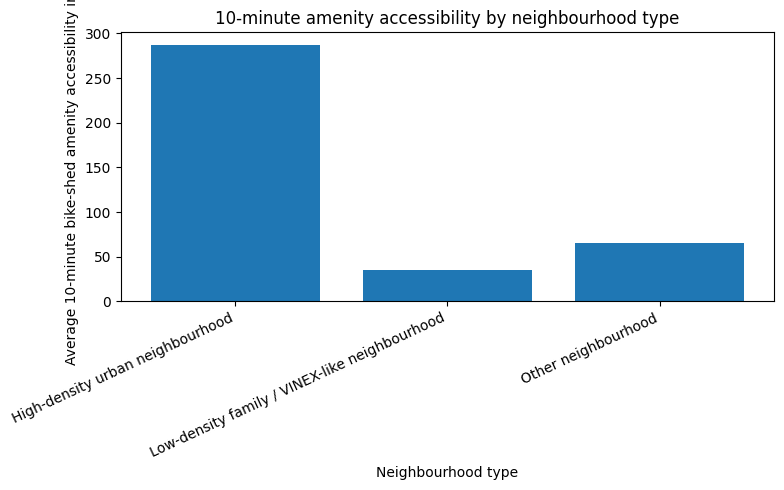

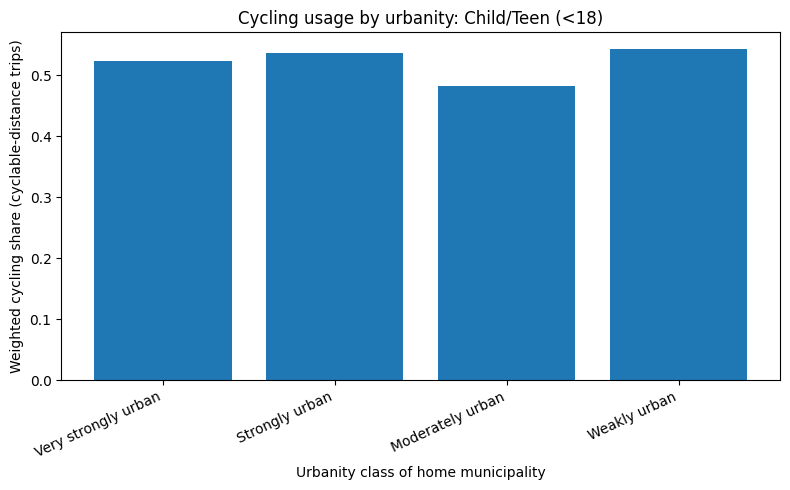

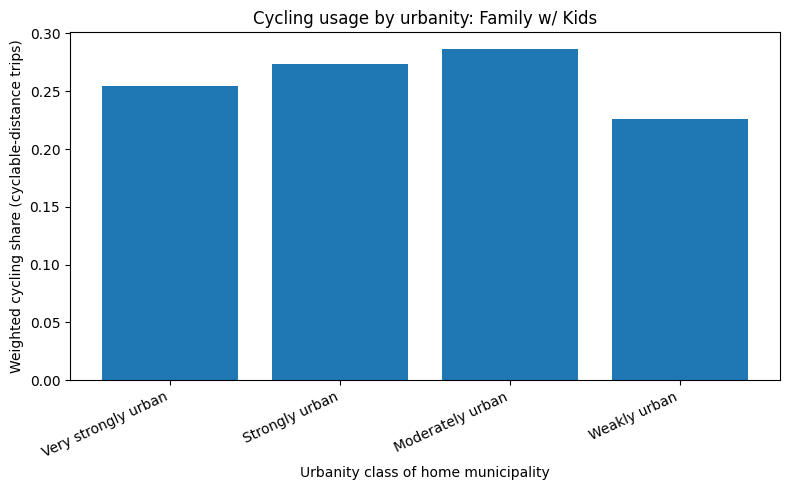

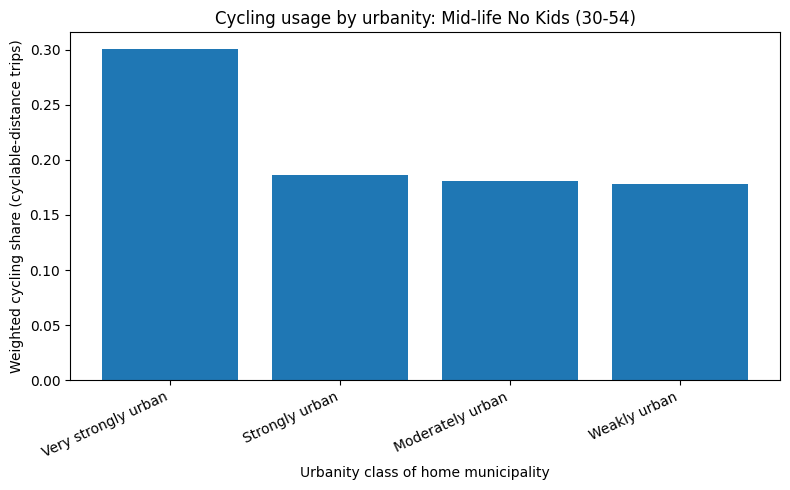

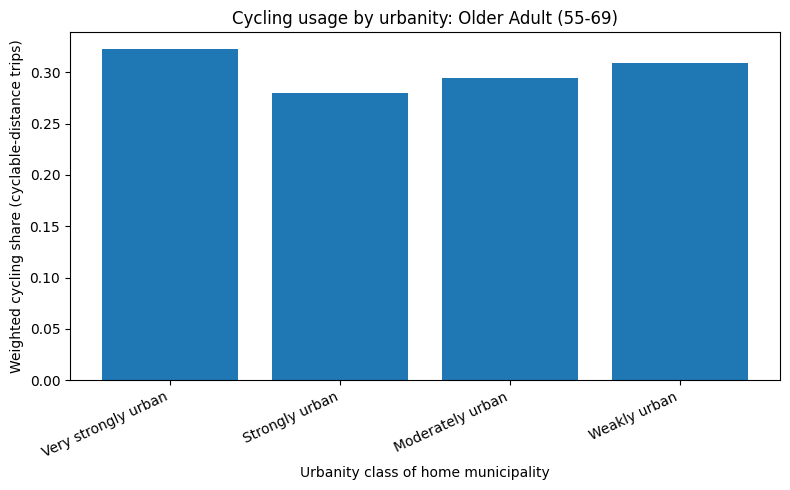

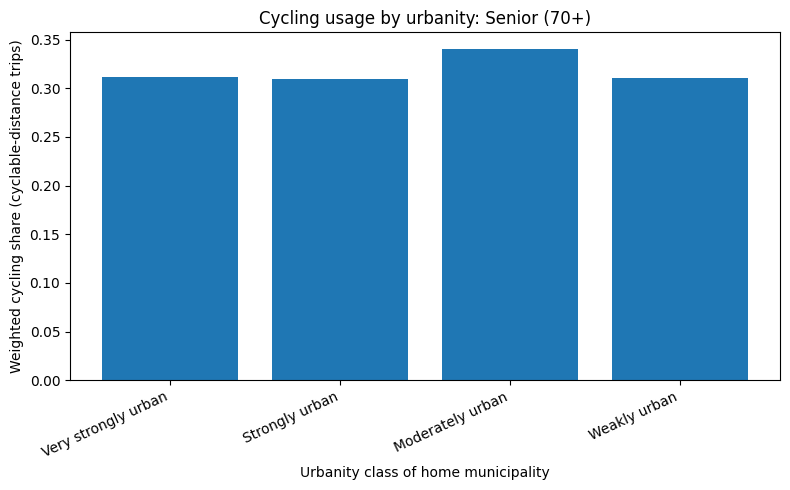

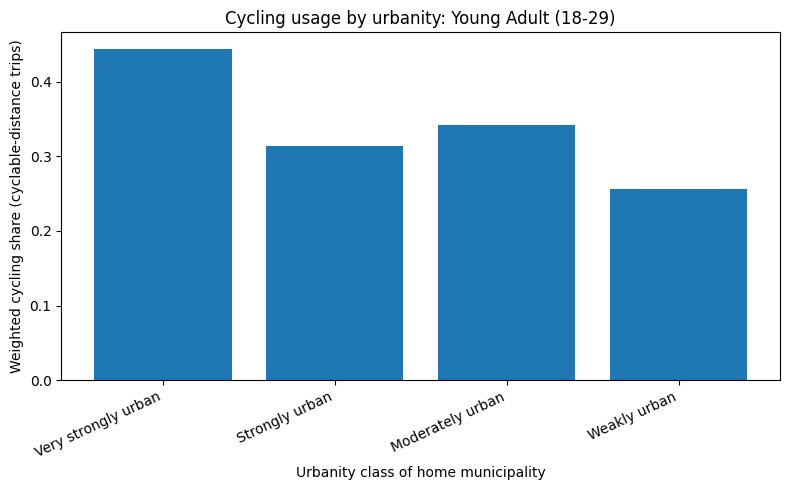

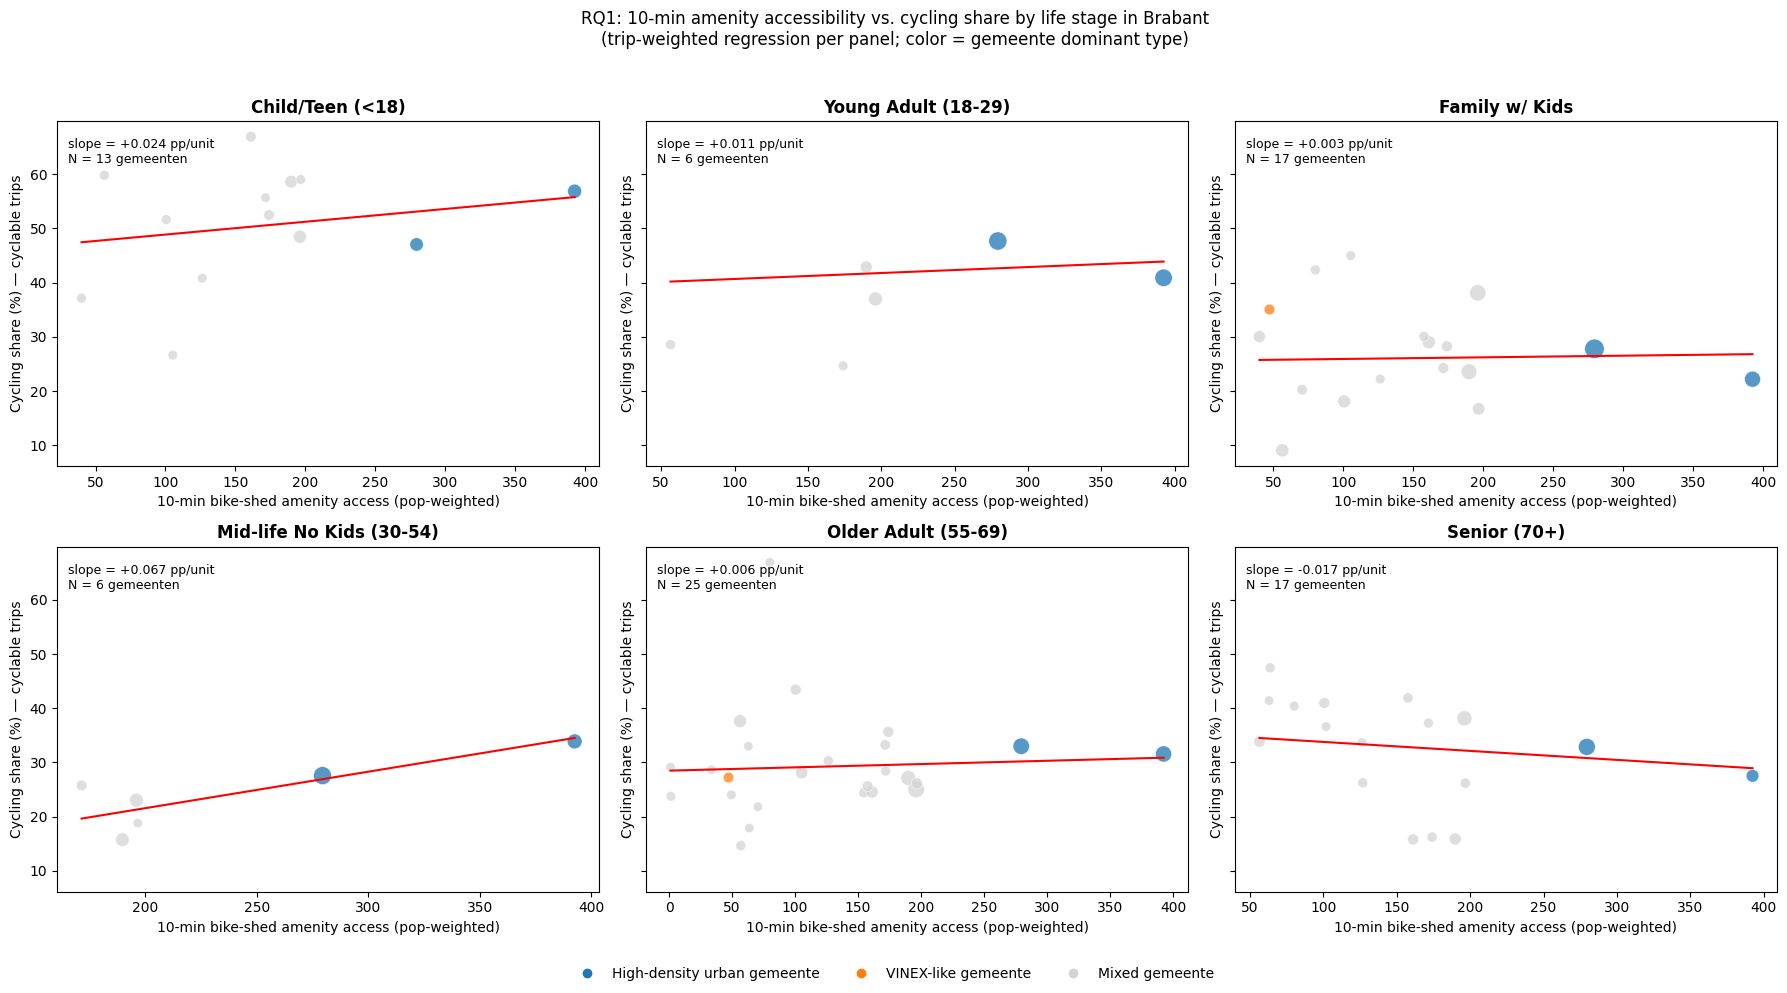

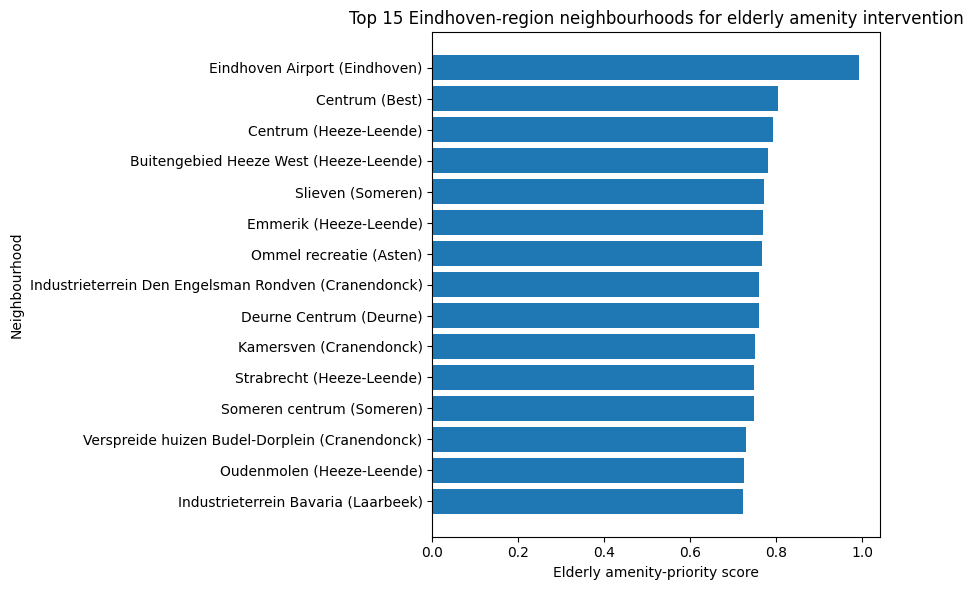

In [13]:
# -------------------------------------------------------
# Figure 1: Accessibility by neighbourhood type
# -------------------------------------------------------
fig_data = summary_eindhoven_type.copy()

plt.figure(figsize=(8, 5))
plt.bar(fig_data["neighbourhood_type"], fig_data["avg_total_access"])
plt.ylabel("Average 10-minute bike-shed amenity accessibility index")
plt.xlabel("Neighbourhood type")
plt.title("10-minute amenity accessibility by neighbourhood type")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(OUT / "fig_topic1_accessibility_by_neighbourhood_type.png", dpi=300)
plt.show()

# -------------------------------------------------------
# Figure 2: RQ1 cycling share by life stage and urbanity
# -------------------------------------------------------
odin_rq1 = pd.read_csv(OUT / "03_odin_rq1_life_stage_urbanity.csv")

sted_labels = {
    1: "Very strongly urban",
    2: "Strongly urban",
    3: "Moderately urban",
    4: "Weakly urban",
    5: "Non-urban",
}
odin_rq1["urbanity_label"] = odin_rq1["Sted"].map(sted_labels)
odin_rq1_plot = odin_rq1[odin_rq1["n_trips_unweighted"] >= 50].copy()

for life_stage in odin_rq1_plot["life_stage"].dropna().unique():
    sub = odin_rq1_plot[odin_rq1_plot["life_stage"] == life_stage].copy()
    sub = sub.sort_values("Sted")

    plt.figure(figsize=(8, 5))
    plt.bar(sub["urbanity_label"], sub["cycling_share"])
    plt.ylabel("Weighted cycling share (cyclable-distance trips)")
    plt.xlabel("Urbanity class of home municipality")
    plt.title(f"Cycling usage by urbanity: {life_stage}")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    filename = (
        "fig_rq1_cycling_share_"
        + life_stage.replace("/", "-").replace(" ", "_")
                    .replace("(", "").replace(")", "")
                    .replace("+", "plus").replace("<", "lt").replace(">", "gt")
        + ".png"
    )
    plt.savefig(OUT / filename, dpi=300)
    plt.show()

# -------------------------------------------------------
# Figure 3: RQ1 access-usage scatter by life stage
# -------------------------------------------------------
rq1 = pd.read_csv(OUT / "table_rq1_municipality_access_usage.csv")
rq1_plot = rq1[rq1["n_trips_unweighted"] >= 50].copy()
rq1_plot = rq1_plot.dropna(subset=["pop_weighted_total_access", "cycling_share"])

LIFE_ORDER = [
    "Child/Teen (<18)", "Young Adult (18-29)", "Family w/ Kids",
    "Mid-life No Kids (30-54)", "Older Adult (55-69)", "Senior (70+)",
]
TYPE_COLORS = {
    "High-density urban gemeente": "tab:blue",
    "VINEX-like gemeente": "tab:orange",
    "Mixed gemeente": "lightgray",
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=True)
for ax, ls in zip(axes.flatten(), LIFE_ORDER):
    sub = rq1_plot[rq1_plot["life_stage"] == ls]
    if len(sub) == 0:
        ax.set_title(f"{ls}\n(no data)", fontweight="bold")
        continue
    for dt, col in TYPE_COLORS.items():
        s2 = sub[sub["dominant_type"] == dt]
        if len(s2) == 0:
            continue
        ax.scatter(
            s2["pop_weighted_total_access"],
            s2["cycling_share"] * 100,
            s=s2["n_trips_unweighted"] / 2 + 20,
            alpha=0.75,
            color=col,
            label=dt,
            edgecolor="white",
            linewidth=0.5,
        )
    if len(sub) >= 4:
        x = sub["pop_weighted_total_access"].values
        y = sub["cycling_share"].values * 100
        w = sub["weighted_trips"].values
        z = np.polyfit(x, y, 1, w=w)
        xs = np.linspace(x.min(), x.max(), 50)
        ax.plot(xs, np.poly1d(z)(xs), color="red", linewidth=1.5)
        slope_pct_per_unit = z[0]
        ax.text(
            0.02, 0.95,
            f"slope = {slope_pct_per_unit:+.3f} pp/unit\nN = {len(sub)} gemeenten",
            transform=ax.transAxes, fontsize=9, va="top",
        )
    ax.set_title(ls, fontweight="bold")
    ax.set_xlabel("10-min bike-shed amenity access (pop-weighted)")
    ax.set_ylabel("Cycling share (%) — cyclable trips")

# Legend once, outside
handles, labels = [], []
for dt, col in TYPE_COLORS.items():
    handles.append(plt.Line2D([], [], marker="o", linestyle="", color=col, label=dt))
    labels.append(dt)
fig.legend(handles=handles, labels=labels, loc="lower center", ncol=3, frameon=False)

fig.suptitle(
    "RQ1: 10-min amenity accessibility vs. cycling share by life stage in Brabant\n"
    "(trip-weighted regression per panel; color = gemeente dominant type)",
    fontsize=12,
)
plt.tight_layout(rect=[0, 0.04, 1, 0.96])
plt.savefig(OUT / "fig_rq1_access_usage_corrected.png", dpi=300)
plt.show()

# -------------------------------------------------------
# Figure 4: RQ2 priority neighbourhoods
# -------------------------------------------------------
priority = pd.read_csv(OUT / "table_rq2_eindhoven_policy_priority_neighbourhoods.csv").head(15)

plt.figure(figsize=(9, 6))
plt.barh(
    priority["buurtnaam"] + " (" + priority["gemeente"] + ")",
    priority["elderly_amenity_priority_score"],
)
plt.xlabel("Elderly amenity-priority score")
plt.ylabel("Neighbourhood")
plt.title("Top 15 Eindhoven-region neighbourhoods for elderly amenity intervention")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(OUT / "fig_rq2_top15_elderly_amenity_priority.png", dpi=300)
plt.show()

### 10b. Heatmap — cycling share by life stage × urbanity

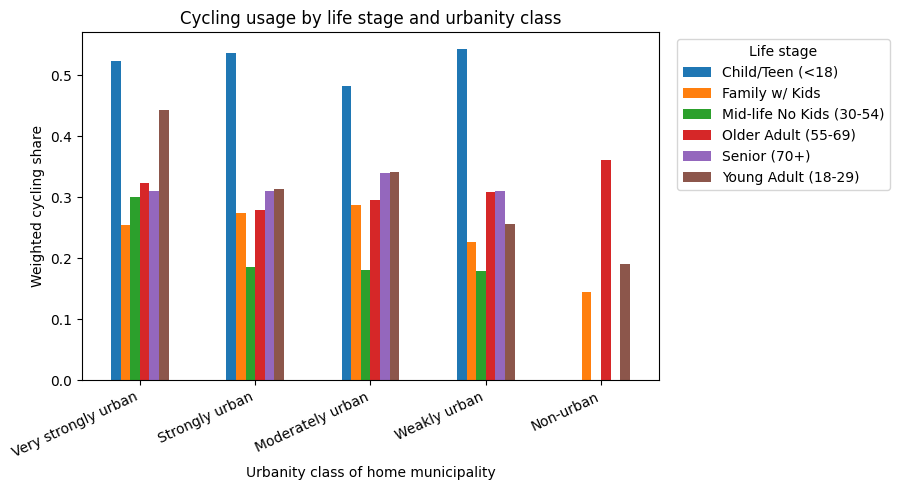

In [14]:
odin_rq1 = pd.read_csv(OUT / "03_odin_rq1_life_stage_urbanity.csv")

sted_labels = {
    1: "Very strongly urban",
    2: "Strongly urban",
    3: "Moderately urban",
    4: "Weakly urban",
    5: "Non-urban"
}

odin_rq1["urbanity_label"] = odin_rq1["Sted"].map(sted_labels)

# Only keep groups with enough observations
plot_data = odin_rq1[odin_rq1["n_trips_unweighted"] >= 15].copy()

pivot = plot_data.pivot(
    index="urbanity_label",
    columns="life_stage",
    values="cycling_share"
)

order = ["Very strongly urban", "Strongly urban", "Moderately urban", "Weakly urban", "Non-urban"]
pivot = pivot.reindex([x for x in order if x in pivot.index])

ax = pivot.plot(kind="bar", figsize=(9, 5))
ax.set_ylabel("Weighted cycling share")
ax.set_xlabel("Urbanity class of home municipality")
ax.set_title("Cycling usage by life stage and urbanity class")
ax.legend(title="Life stage", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(OUT / "fig_rq1_cycling_share_life_stage_urbanity_grouped.png", dpi=300)
#plt.show()

### 10c. Scatter — utilitarian vs leisure/social access, sized by elderly share

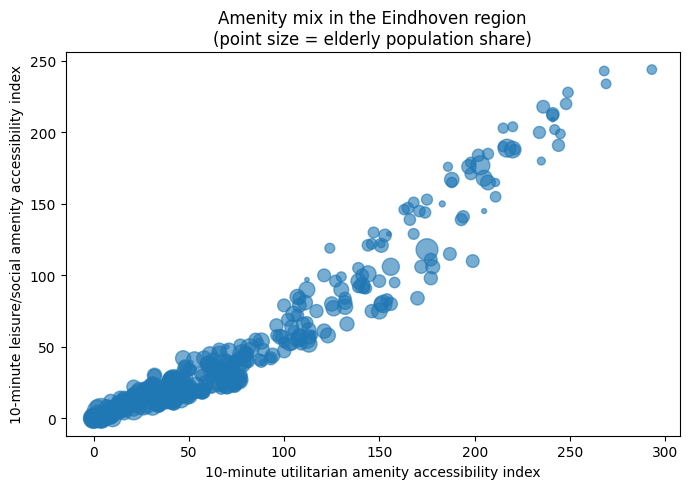

In [15]:
access = pd.read_csv(OUT / "05_accessibility_context_buurten.csv")

eindhoven_region_codes = [
    743, 753, 762, 770, 772, 794, 820, 823, 847, 848, 858, 861, 866,
    1652, 1658, 1659, 1667, 1706, 1724, 1728, 1771
]

eindhoven = access[access["gm_code_int"].isin(eindhoven_region_codes)].copy()

plt.figure(figsize=(7, 5))
plt.scatter(
    eindhoven["bikeshed_utilitarian_amenities"],
    eindhoven["bikeshed_leisure_social_amenities"],
    s=(eindhoven["elderly_share"].fillna(0) * 400) + 10,
    alpha=0.6
)

plt.xlabel("10-minute utilitarian amenity accessibility index")
plt.ylabel("10-minute leisure/social amenity accessibility index")
plt.title("Amenity mix in the Eindhoven region\n(point size = elderly population share)")

plt.tight_layout()
plt.savefig(OUT / "fig_rq2_amenity_mix_eindhoven_region.png", dpi=300)
#plt.show()

## 11. Export LaTeX Tables

Four tables are written to `output/latex_tables/` for direct inclusion in the report:

| File | Caption |
|------|---------|
| `table_accessibility_neighbourhood_type.tex` | Avg 10-min bike-shed accessibility by neighbourhood type |
| `table_odin_cycling_life_stage_urbanity.tex` | Weighted cycling/car shares by life stage × urbanity |
| `table_elderly_regional_mobility.tex` | Weighted elderly mobility indicators for Zuidoost-Noord-Brabant |
| `table_top10_priority_neighbourhoods.tex` | Top 10 Eindhoven-region neighbourhoods by elderly amenity-priority score |


In [16]:
LATEX_OUT = OUT / "latex_tables"
LATEX_OUT.mkdir(exist_ok=True)

# 1. Accessibility by neighbourhood type
access_type = pd.read_csv(OUT / "table_eindhoven_accessibility_by_neighbourhood_type.csv")

access_type_clean = access_type[[
    "neighbourhood_type",
    "n_buurten",
    "avg_total_access",
    "avg_utilitarian_access",
    "avg_leisure_social_access",
    "avg_elderly_share",
    "avg_family_household_share"
]].copy()

access_type_clean = access_type_clean.round({
    "avg_total_access": 1,
    "avg_utilitarian_access": 1,
    "avg_leisure_social_access": 1,
    "avg_elderly_share": 3,
    "avg_family_household_share": 3
})

access_type_clean.to_latex(
    LATEX_OUT / "table_accessibility_neighbourhood_type.tex",
    index=False,
    caption="Average 10-minute bike-shed accessibility by neighbourhood type in the Eindhoven region.",
    label="tab:access_neighbourhood_type",
    escape=True,
    float_format="%.3f"
)

# 2. ODiN cycling share by life stage and urbanity
odin_rq1 = pd.read_csv(OUT / "03_odin_rq1_life_stage_urbanity.csv")

sted_labels = {
    1: "Very strongly urban",
    2: "Strongly urban",
    3: "Moderately urban",
    4: "Weakly urban",
    5: "Non-urban"
}

odin_rq1["urbanity"] = odin_rq1["Sted"].map(sted_labels)

odin_rq1_clean = odin_rq1[
    odin_rq1["n_trips_unweighted"] >= 15
][[
    "life_stage",
    "urbanity",
    "n_trips_unweighted",
    "cycling_share",
    "car_share"
]].copy()

odin_rq1_clean = odin_rq1_clean.round({
    "cycling_share": 3,
    "car_share": 3
})

odin_rq1_clean.to_latex(
    LATEX_OUT / "table_odin_cycling_life_stage_urbanity.tex",
    index=False,
    caption="Weighted cycling and car shares by life stage and urbanity class in Noord-Brabant.",
    label="tab:cycling_life_stage_urbanity",
    escape=True,
    float_format="%.3f"
)

# 3. Elderly regional mobility summary
elderly_summary = pd.read_csv(OUT / "table_rq2_regional_elderly_car_dependency.csv")

elderly_summary_clean = elderly_summary[[
    "region",
    "n_trips_unweighted",
    "elderly_cycling_share",
    "elderly_car_share",
    "elderly_utilitarian_trip_share",
    "elderly_leisure_social_trip_share"
]].copy()

elderly_summary_clean = elderly_summary_clean.round({
    "elderly_cycling_share": 3,
    "elderly_car_share": 3,
    "elderly_utilitarian_trip_share": 3,
    "elderly_leisure_social_trip_share": 3
})

elderly_summary_clean.to_latex(
    LATEX_OUT / "table_elderly_regional_mobility.tex",
    index=False,
    caption="Weighted elderly mobility indicators for Zuidoost-Noord-Brabant.",
    label="tab:elderly_regional_mobility",
    escape=True,
    float_format="%.3f"
)

# 4. Top 10 priority neighbourhoods
priority = pd.read_csv(OUT / "table_rq2_eindhoven_policy_priority_neighbourhoods.csv")

priority_top10 = priority.head(10)[[
    "buurtnaam",
    "gemeente",
    "elderly_share",
    "bikeshed_utilitarian_amenities",
    "bikeshed_leisure_social_amenities",
    "elderly_amenity_priority_score"
]].copy()

priority_top10 = priority_top10.round({
    "elderly_share": 3,
    "bikeshed_utilitarian_amenities": 1,
    "bikeshed_leisure_social_amenities": 1,
    "elderly_amenity_priority_score": 3
})

priority_top10.to_latex(
    LATEX_OUT / "table_top10_priority_neighbourhoods.tex",
    index=False,
    caption="Top 10 Eindhoven-region neighbourhoods by elderly amenity-priority score.",
    label="tab:top10_priority_neighbourhoods",
    escape=True,
    float_format="%.3f"
)

print("Saved LaTeX tables to:", LATEX_OUT)

Saved LaTeX tables to: c:\Users\joane\Documents\MASTER\Q4\AI BUSINESS OPERATIONS\1BM130 project\output\latex_tables


## 12. Additional Figures & Tables for Report (Section 3.6)

Three new outputs that complement the existing descriptive analysis:

| Output | File | Report location |
|--------|------|-----------------|
| **Table**: cycling share by life stage × gemeente type (pivot) | `table_rq1_contrast_pivot.csv` | Section 3.6 / Table 3.X |
| **Figure**: contrast heatmap (cycling share %) | `fig_new_D_contrast_heatmap.png` | Section 3.6 / Figure 3.X |
| **Figure**: Urban cycling advantage gap (pp) | `fig_new_B_cycling_gap_heatmap.png` | Section 3.6 / Figure 3.X |
| **Model B coefficients**: `is_bike ~ access_z × dominant_type` | `table_model_B_coefficients.csv` | Appendix B |


In [17]:
# -------------------------------------------------------
# 12a. Contrast pivot: cycling share by life_stage x gemeente type
# -------------------------------------------------------
import numpy as np

contrast = pd.read_csv(OUT / "table_rq1_contrast_life_stage_dominant_type.csv")

LIFE_ORDER = [
    "Child/Teen (<18)", "Young Adult (18-29)", "Mid-life No Kids (30-54)",
    "Family w/ Kids", "Older Adult (55-69)", "Senior (70+)",
]

pivot = (
    contrast[contrast["reliable"]]
    .pivot(index="life_stage", columns="dominant_type",
           values="trip_weighted_cycling_share")
    .rename(columns={
        "High-density urban gemeente": "Urban",
        "VINEX-like gemeente": "VINEX",
        "Mixed gemeente": "Mixed",
    })
    .reindex(LIFE_ORDER)
)

pivot["Urban–Mixed gap (pp)"] = (pivot.get("Urban", np.nan) - pivot.get("Mixed", np.nan)) * 100
pivot["Urban–VINEX gap (pp)"] = (pivot.get("Urban", np.nan) - pivot.get("VINEX", np.nan)) * 100

for c in ["Urban", "Mixed", "VINEX"]:
    if c in pivot.columns:
        pivot[c] = (pivot[c] * 100).round(1)
pivot["Urban–Mixed gap (pp)"] = pivot["Urban–Mixed gap (pp)"].round(1)
pivot["Urban–VINEX gap (pp)"] = pivot["Urban–VINEX gap (pp)"].round(1)

pivot.to_csv(OUT / "table_rq1_contrast_pivot.csv")
print("Saved: table_rq1_contrast_pivot.csv")
print(pivot.to_string())


Saved: table_rq1_contrast_pivot.csv
dominant_type             Urban  Mixed  VINEX  Urban–Mixed gap (pp)  Urban–VINEX gap (pp)
life_stage                                                                               
Child/Teen (<18)           52.3   51.7    NaN                   0.6                   NaN
Young Adult (18-29)        44.4   29.5    NaN                  14.9                   NaN
Mid-life No Kids (30-54)   30.1   18.0    NaN                  12.1                   NaN
Family w/ Kids             25.5   25.4   37.4                   0.0                 -11.9
Older Adult (55-69)        32.3   30.0   24.4                   2.3                   7.9
Senior (70+)               31.1   32.6   22.3                  -1.5                   8.9


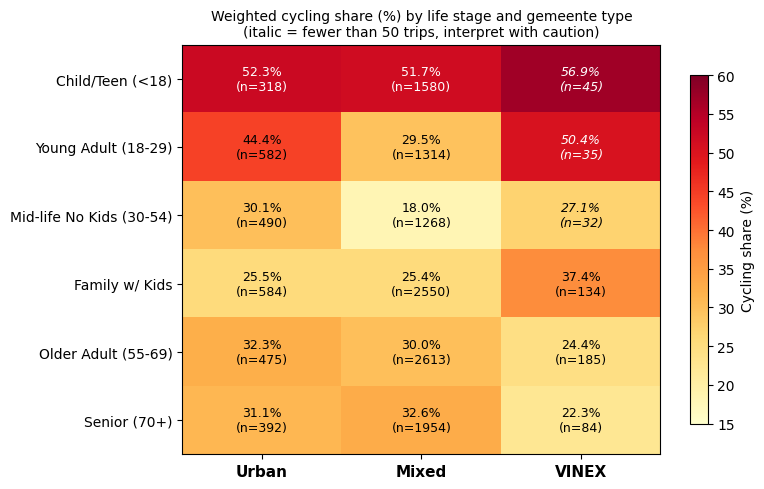

Saved: fig_new_D_contrast_heatmap.png


In [18]:
# -------------------------------------------------------
# 12b. Figure: contrast heatmap — cycling share % by life stage x gemeente type
# -------------------------------------------------------
TYPE_ORDER_SHORT = ["Urban", "Mixed", "VINEX"]
TYPE_MAP = {
    "High-density urban gemeente": "Urban",
    "Mixed gemeente": "Mixed",
    "VINEX-like gemeente": "VINEX",
}

contrast["type_short"] = contrast["dominant_type"].map(TYPE_MAP)

matrix   = np.full((len(LIFE_ORDER), 3), np.nan)
n_matrix = np.full((len(LIFE_ORDER), 3), 0, dtype=int)
rel_mat  = np.zeros((len(LIFE_ORDER), 3), dtype=bool)

for _, row in contrast.iterrows():
    r = LIFE_ORDER.index(row["life_stage"])
    c = TYPE_ORDER_SHORT.index(row["type_short"])
    matrix[r, c]   = row["trip_weighted_cycling_share"] * 100
    n_matrix[r, c] = int(row["n_trips_unweighted"])
    rel_mat[r, c]  = row["reliable"]

fig, ax = plt.subplots(figsize=(8, 5))
masked = np.ma.masked_invalid(matrix)
im = ax.imshow(masked, cmap="YlOrRd", aspect="auto", vmin=15, vmax=60)

for i in range(len(LIFE_ORDER)):
    for j in range(3):
        val = matrix[i, j]
        n   = n_matrix[i, j]
        rel = rel_mat[i, j]
        if not np.isnan(val):
            color  = "white" if val > 45 else "black"
            fstyle = "normal" if rel else "italic"
            ax.text(j, i, f"{val:.1f}%\n(n={n})",
                    ha="center", va="center", fontsize=9,
                    color=color, fontstyle=fstyle)
        else:
            ax.text(j, i, "—", ha="center", va="center",
                    fontsize=11, color="gray")

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(TYPE_ORDER_SHORT, fontsize=11, fontweight="bold")
ax.set_yticks(range(len(LIFE_ORDER)))
ax.set_yticklabels(LIFE_ORDER, fontsize=10)
ax.set_title(
    "Weighted cycling share (%) by life stage and gemeente type\n"
    "(italic = fewer than 50 trips, interpret with caution)",
    fontsize=10,
)
plt.colorbar(im, ax=ax, label="Cycling share (%)", shrink=0.85)
plt.tight_layout()
plt.savefig(OUT / "fig_new_D_contrast_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig_new_D_contrast_heatmap.png")


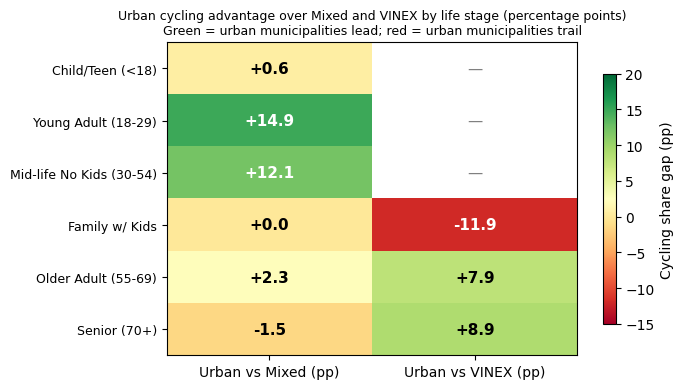

Saved: fig_new_B_cycling_gap_heatmap.png


In [19]:
# -------------------------------------------------------
# 12c. Figure: Urban cycling advantage gap (pp) over Mixed and VINEX
# -------------------------------------------------------
gap_cols = ["Urban–Mixed gap (pp)", "Urban–VINEX gap (pp)"]
gap_data = pivot[gap_cols].copy()

fig, ax = plt.subplots(figsize=(7, 4))
im2 = ax.imshow(gap_data.values, cmap="RdYlGn", aspect="auto", vmin=-15, vmax=20)

ax.set_xticks([0, 1])
ax.set_xticklabels(["Urban vs Mixed (pp)", "Urban vs VINEX (pp)"], fontsize=10)
ax.set_yticks(range(len(gap_data)))
ax.set_yticklabels(gap_data.index, fontsize=9)

for i in range(len(gap_data)):
    for j in range(2):
        val = gap_data.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:+.1f}",
                    ha="center", va="center", fontsize=11, fontweight="bold",
                    color="white" if abs(val) > 10 else "black")
        else:
            ax.text(j, i, "—", ha="center", va="center",
                    fontsize=11, color="gray")

plt.colorbar(im2, ax=ax, label="Cycling share gap (pp)", shrink=0.8)
ax.set_title(
    "Urban cycling advantage over Mixed and VINEX by life stage (percentage points)\n"
    "Green = urban municipalities lead; red = urban municipalities trail",
    fontsize=9,
)
plt.tight_layout()
plt.savefig(OUT / "fig_new_B_cycling_gap_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig_new_B_cycling_gap_heatmap.png")


In [20]:
# -------------------------------------------------------
# 12d. Model B: is_bike ~ access_z * dominant_type  (new regression)
# -------------------------------------------------------
trips_rq1_b = trips_rq1.copy()   # reuse standardised trips_rq1 from cell 20

m_b = smf.wls(
    "is_bike ~ access_z * C(dominant_type, Treatment(reference='Mixed gemeente'))",
    data=trips_rq1_b,
    weights=trips_rq1_b["weight_v"],
).fit(cov_type="HC1")

print("=== Model B: is_bike ~ access_z * dominant_type ===")
print(m_b.summary().tables[1])

# Clean coefficient table
res_b = m_b.summary2().tables[1].reset_index()
res_b.columns = ["Term", "Coef", "Std Err", "z", "P>|z|", "[0.025", "0.975]"]

rename_b = {
    "Intercept": "Intercept (Mixed gemeente baseline)",
    "C(dominant_type, Treatment(reference='Mixed gemeente'))[T.High-density urban gemeente]":
        "High-density urban gemeente",
    "C(dominant_type, Treatment(reference='Mixed gemeente'))[T.VINEX-like gemeente]":
        "VINEX-like gemeente",
    "access_z": "access_z (main effect)",
    "access_z:C(dominant_type, Treatment(reference='Mixed gemeente'))[T.High-density urban gemeente]":
        "access_z × Urban",
    "access_z:C(dominant_type, Treatment(reference='Mixed gemeente'))[T.VINEX-like gemeente]":
        "access_z × VINEX",
}
res_b["Term"] = res_b["Term"].map(rename_b).fillna(res_b["Term"])
res_b = res_b.round({"Coef": 4, "Std Err": 4, "z": 3, "P>|z|": 3,
                     "[0.025": 4, "0.975]": 4})

res_b.to_csv(OUT / "table_model_B_coefficients.csv", index=False)
print("\nSaved: table_model_B_coefficients.csv")
print(res_b.to_string(index=False))
print(f"\nN trips used: {len(trips_rq1_b)}")
print(f"Model B pseudo-R²: {m_b.rsquared:.4f}  (vs Model A: {m1.rsquared:.4f})")


=== Model B: is_bike ~ access_z * dominant_type ===
                                                                                                      coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                                           0.3163      0.006     57.090      0.000       0.305       0.327
C(dominant_type, Treatment(reference='Mixed gemeente'))[T.High-density urban gemeente]              0.0298      0.032      0.925      0.355      -0.033       0.093
C(dominant_type, Treatment(reference='Mixed gemeente'))[T.VINEX-like gemeente]                     -0.1561      0.276     -0.565      0.572      -0.698       0.386
access_z                                                                                            0.0082      0.008      1.035